# Protein–Ligand Binding Affinity Prediction

This notebook covers the full pipeline for predicting whether a protein–ligand pair binds:

1. **Data exploration** — raw KIBA dataset (UniProt IDs × PubChem CIDs, KIBA threshold < 12.1)
2. **Data preparation** — `DataPreprocessor` (dedup, label, generate negatives), `ESM2Encoder`, `LigandEncoder`
3. **Feature engineering** — `FeatureBuilder` → 4 789-dim flat matrix or separate protein/ligand blocks
4. **Model training** — Logistic Regression, Random Forest, XGBoost, LightGBM, InteractionMLP
5. **Evaluation** — accuracy, F1-binary, F1-macro, ROC-AUC, PR-AUC, confusion matrices
6. **Cross-validation** — `ModelEvaluator.cross_validate()` with protein-aware `StratifiedGroupKFold`
7. **One-command pipeline** — `TrainingPipeline.run()` with cold-protein splits

The demo in sections 4–7 uses synthetic data (300 samples, 50 features) so it runs in under a minute on any laptop.  
Install the package first: `pip install -e ".[dev]"` from the repo root.

## 1. Setup

In [ ]:
import sys, os, warnings
from pathlib import Path

# Resolve repo root regardless of where the kernel was launched from
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
print(f"REPO_ROOT: {REPO_ROOT}")
print("Setup complete.")

---
## 2. Data Exploration

The raw dataset contains UniProt protein IDs, PubChem ligand IDs, and KIBA binding scores.  
`kiba_score_estimated == True` means the score was **imputed** (noisy); `False` = directly measured.  
**Binding threshold: KIBA score < 12.1 → bound** (lower score = stronger affinity, He et al. 2017).

In [ ]:
csv_path = REPO_ROOT / "Data" / "Drug_Discovery_dataset.csv"
raw = pd.read_csv(csv_path)

print(f"Shape: {raw.shape}")
raw.head()

In [ ]:
# Keep all rows regardless of estimated flag (matches DataPreprocessor default: keep_only_measured=False)
data = raw.dropna(subset=["UniProt_ID", "pubchem_cid", "kiba_score"])

print(f"After dropping NaN: {len(data):,} rows")
print(f"Unique proteins : {data['UniProt_ID'].nunique():,}")
print(f"Unique ligands  : {data['pubchem_cid'].nunique():,}")
print(f"\nkiba_score_estimated breakdown:")
print(data["kiba_score_estimated"].value_counts().to_string())
print(f"\nKIBA score stats:")
data["kiba_score"].describe()

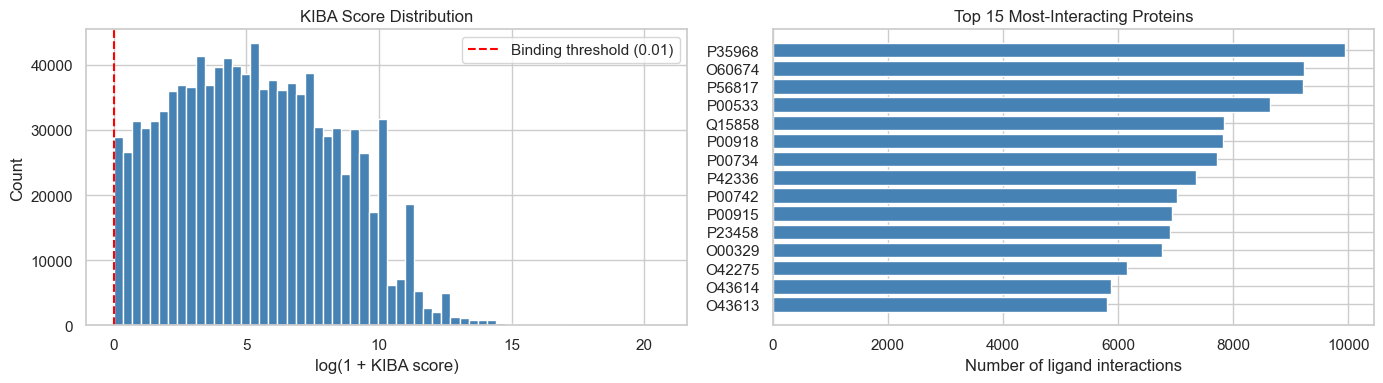

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# KIBA score distribution (log scale)
axes[0].hist(np.log1p(data["kiba_score"]), bins=60, color="steelblue", edgecolor="white")
axes[0].axvline(np.log1p(0.01), color="red", linestyle="--", label="Binding threshold (0.01)")
axes[0].set_xlabel("log(1 + KIBA score)")
axes[0].set_ylabel("Count")
axes[0].set_title("KIBA Score Distribution")
axes[0].legend()

# Proteins with most ligand interactions
top_proteins = data["UniProt_ID"].value_counts().head(15)
axes[1].barh(top_proteins.index[::-1], top_proteins.values[::-1], color="steelblue")
axes[1].set_xlabel("Number of ligand interactions")
axes[1].set_title("Top 15 Most-Interacting Proteins")

plt.tight_layout()
plt.show()

In [5]:
# Duplicate protein-ligand pairs (multiple experimental measurements)
dupes = data[data.duplicated(subset=["UniProt_ID", "pubchem_cid"], keep=False)]
print(f"Duplicate rows: {len(dupes):,} ({100*len(dupes)/len(data):.1f}% of data)")
print("\nExample — multiple KIBA scores for the same pair:")
dupes.head(4)

Duplicate rows: 45,116 (4.2% of data)

Example — multiple KIBA scores for the same pair:


,UniProt_ID,pubchem_cid,kiba_score,kiba_score_estimated
725,B0BNF9,56840672.0,11100.000,True
726,B0BNF9,56840672.0,11100.000,True
922,C7C422,118256794.0,0.497,True
923,C7C422,118256794.0,0.314,True


In [ ]:
# Resolve duplicates by averaging KIBA scores per protein–ligand pair
data["kiba_score"] = data.groupby(["UniProt_ID", "pubchem_cid"])["kiba_score"].transform("mean")
data_unique = data.drop_duplicates(subset=["UniProt_ID", "pubchem_cid"])

print(f"After deduplication: {len(data_unique):,} unique pairs")

# Binding label: KIBA < 12.1 → bound=1 (lower score = stronger binding, He et al. 2017)
KIBA_THRESHOLD = 12.1
data_unique = data_unique.copy()
data_unique["bound"] = (data_unique["kiba_score"] < KIBA_THRESHOLD).astype(int)
print(f"\nBound (1): {data_unique['bound'].sum():,}  |  Not bound (0): {(data_unique['bound']==0).sum():,}")
print(f"Positive rate: {data_unique['bound'].mean():.4f}")

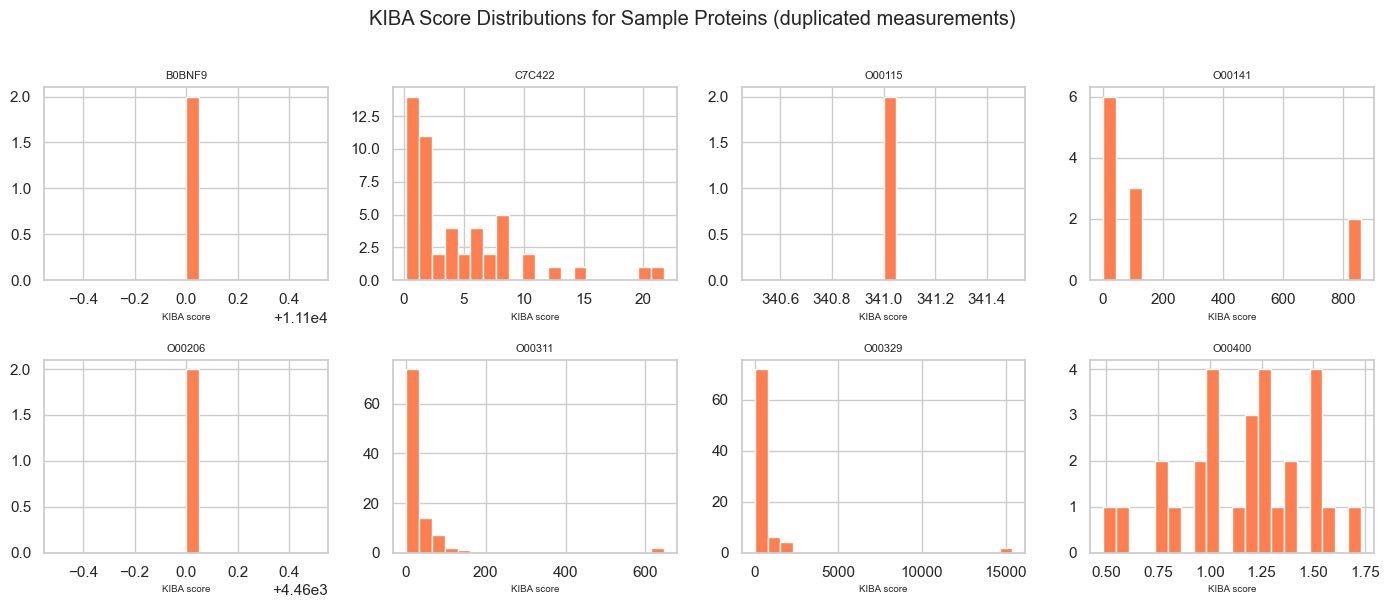

In [7]:
# KIBA score spread for a sample of proteins with duplicates
dup_proteins = dupes["UniProt_ID"].unique()[:8]
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, uid in zip(axes.flatten(), dup_proteins):
    scores = dupes[dupes["UniProt_ID"] == uid]["kiba_score"].values
    ax.hist(scores, bins=20, edgecolor="white", color="coral")
    ax.set_title(uid, fontsize=8)
    ax.set_xlabel("KIBA score", fontsize=7)
fig.suptitle("KIBA Score Distributions for Sample Proteins (duplicated measurements)", y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Data Preparation Pipeline

The `plbind.data` module handles three steps:

| Step | Class | What it does |
|------|-------|--------------|
| `DataPreprocessor` | `plbind.data.preprocessor` | Loads, deduplicates, labels (KIBA < 12.1 = bound), generates property-matched negatives |
| `ESM2Encoder` | `plbind.data.protein_encoder` | ESM-2 protein embeddings, mean+max pooling → **2 560-dim** per protein |
| `LigandEncoder` | `plbind.data.ligand_encoder` | Morgan (1 024) + MACCS (166) + atom-pair (1 024) fingerprints + **15** physicochemical descriptors |

> **Note:** Full data preparation requires internet access and an ESM-2 model download (~280 MB for the 35M-parameter model). See `src/plbind/data/` for full implementations.

In [ ]:
# --- Full data preparation pipeline ---
#
# from plbind.data.preprocessor import DataPreprocessor
# from plbind.data.protein_encoder import ESM2Encoder
# from plbind.data.ligand_encoder import LigandEncoder
#
# # Step 1: preprocess raw KIBA data and generate negatives
# preprocessor = DataPreprocessor(
#     kiba_threshold=12.1,               # bound=1 when kiba_score < threshold
#     kiba_binder_is_below=True,
#     negative_ratio=1.0,                # one synthetic negative per positive
#     use_property_matched_decoys=True,  # DUD-E style (requires SMILES + RDKit)
#     random_state=42,
# )
# df_labeled = preprocessor.preprocess(
#     data_path=str(REPO_ROOT / "Data" / "Drug_Discovery_dataset.csv"),
#     smiles_map=smiles_map,             # dict {pubchem_cid: SMILES}
# )
# # → DataFrame with columns: UniProt_ID, pubchem_cid, kiba_score, bound
#
# # Step 2: encode proteins with ESM-2 (Meta, 2022)
# encoder = ESM2Encoder(
#     model_name="facebook/esm2_t12_35M_UR50D",
#     pooling="mean_max",  # concat(mean, max) pooling → 2 × embed_dim = 2560 dims
# )
# protein_embs = encoder.encode(df_labeled["UniProt_ID"].unique().tolist())
# # → {UniProt_ID: np.ndarray(2560,)}
#
# # Step 3: encode ligands
# ligand_enc = LigandEncoder()
# cid_to_row, fp_matrix, desc_matrix = ligand_enc.encode(
#     {cid: smiles for cid, smiles in smiles_map.items()}
# )
# # fp_matrix:   scipy.sparse (N_ligs, 2214)  Morgan(1024) + MACCS(166) + atom-pair(1024)
# # desc_matrix: np.ndarray   (N_ligs, 15)    MolWt, LogP, TPSA, RotBonds, HBD, HBA, ...

print("Data preparation code shown above (requires SMILES data and ESM-2 model).")

### Negative sample generation

`DataPreprocessor.preprocess()` generates negatives automatically — no manual shuffling needed.

- **Default strategy**: DUD-E / DEKOIS-style *property-matched decoys* — chemically dissimilar ligands (Tanimoto < 0.4) with similar physicochemistry (MW ±25, LogP ±1.5, same charge and rotatable bonds). Requires SMILES strings and RDKit.
- **Fallback**: random permutation of `pubchem_cid` values (used when RDKit is unavailable or SMILES are missing).

The cell below shows a representative class balance for `negative_ratio=1.0`.

In [ ]:
# Illustrate the balanced dataset produced by DataPreprocessor(negative_ratio=1.0)
# In practice, call:  df_labeled = preprocessor.preprocess(data_path, smiles_map)
n_pos = data_unique["bound"].sum()
n_neg = n_pos  # negative_ratio=1.0

combined_example = pd.DataFrame({"bound": [1] * n_pos + [0] * n_neg})
combined_example = combined_example.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Representative combined dataset: {len(combined_example):,} rows")
print(combined_example["bound"].value_counts().rename({0: "Not bound", 1: "Bound"}).to_string())

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
combined_example["bound"].value_counts().rename({0: "Not bound", 1: "Bound"}).plot.bar(
    ax=ax, color=["coral", "steelblue"], edgecolor="white"
)
ax.set_title("Class Balance (Bound vs Not Bound, negative_ratio=1.0)")
ax.set_ylabel("Count")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

---
## 4. Feature Engineering

Each training sample is a concatenation of three feature blocks built by `FeatureBuilder`:

| Block | Source | Dimensions |
|-------|--------|------------|
| Protein embedding | ESM-2 (`facebook/esm2_t12_35M_UR50D`), mean+max pooling | 2 560 |
| Ligand fingerprints | Morgan counts (r=2, 1024) + MACCS keys (166) + atom-pair (1024) | 2 214 |
| Molecular descriptors | MolWt, LogP, TPSA, RotBonds, HBD, HBA, AromaticRings, FractionCSP3 + 7 more | 15 |
| **Total** | | **4 789** (+ optional 95 auxiliary protein features → 4 884) |

`FeatureBuilder.build()` → flat `(N, 4789)` matrix for sklearn models.  
`FeatureBuilder.build_blocks()` → separate protein / ligand / aux blocks for `InteractionMLP`.

In [ ]:
fig, ax = plt.subplots(figsize=(13, 1.5))
blocks = [
    (0,    2560, "steelblue", "ESM-2 embedding\n(2 560)"),
    (2560, 2214, "coral",     "Ligand fingerprints\nMorgan+MACCS+AP (2 214)"),
    (4774, 15,   "seagreen",  "Descriptors\n(15)"),
]
for start, width, color, label in blocks:
    ax.barh(0, width, left=start, color=color, edgecolor="white", height=0.5)
    ax.text(start + width / 2, 0, label, ha="center", va="center",
            fontsize=8, color="white", fontweight="bold")
ax.set_xlim(0, 4789)
ax.set_yticks([])
ax.set_xlabel("Feature index")
ax.set_title("Feature Vector Layout — 4 789 dimensions per protein–ligand pair")
plt.tight_layout()
plt.show()

In [ ]:
# --- Assembling the feature matrix with FeatureBuilder ---
#
# from plbind.features.feature_builder import FeatureBuilder
#
# builder = FeatureBuilder(
#     protein_embeddings=protein_embs,   # {UniProt_ID: np.ndarray(2560,)}
#     cid_to_row=cid_to_row,             # {pubchem_cid: row_index_in_fp_matrix}
#     fp_matrix=fp_matrix,               # scipy.sparse (N_ligs, 2214)
#     desc_matrix=desc_matrix,           # np.ndarray   (N_ligs, 15)
# )
#
# # Flat matrix for sklearn models (LR, RF, XGBoost, LightGBM):
# X, y, block_map = builder.build(df_labeled)
# # X:         np.ndarray float32  (N, 4789)
# # y:         np.ndarray int32    (N,)
# # block_map: {"protein": slice(0, 2560), "ligand": slice(2560, 4774), "aux": slice(4774, 4789)}
#
# # Separate blocks for InteractionMLP:
# protein_block, ligand_block, aux_block, y = builder.build_blocks(df_labeled)
# # protein_block: float32 (N, 2560)  — ESM-2 embeddings
# # ligand_block:  float32 (N, 2229)  — fingerprint bits + 15 descriptors concatenated
# # aux_block:     None (or float32 (N, 95) if aux_features were supplied to FeatureBuilder)

print("Feature builder code shown above (requires outputs from data prep step).")

---
## 5. Model Training — Quick Demo

We use **synthetic data** (300 samples, 50 features) to demonstrate the pipeline end-to-end.
For production runs, replace `X_demo` / `y_demo` with the output of `FeatureBuilder.build()`.

All ML best practices are active:
- `StandardScaler` fitted on train split only — enforced by `BaseModel.split_data()` (no leakage)
- `class_weight='balanced'` for LR and RF
- Optional `GridSearchCV` tuning via `.tune()` before training
- XGBoost and LightGBM: early stopping using an internal 10 % validation split
- `InteractionMLP`: uses separate protein/ligand blocks + FocalLoss — shown in section 9

In [13]:
# Synthetic demo dataset — replace with real X, y_binary for production
np.random.seed(42)
N_SAMPLES, N_FEATURES = 300, 50
X_demo = pd.DataFrame(np.random.randn(N_SAMPLES, N_FEATURES))
y_demo = pd.Series(np.random.randint(0, 2, N_SAMPLES))

print(f"Demo dataset: {X_demo.shape}")
print(f"Class balance: {y_demo.value_counts().to_dict()}")

Demo dataset: (300, 50)
Class balance: {1: 161, 0: 139}


In [ ]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")  # prevent macOS libomp conflict

from plbind.models.logistic import LogisticRegressionModel
from plbind.models.random_forest import RandomForestModel
from plbind.models.xgboost_model import XGBoostModel
from plbind.models.lightgbm_model import LightGBMModel
from plbind.evaluation.evaluator import ModelEvaluator

trained_models = {}
all_results    = {}

# ── Logistic Regression ──────────────────────────────────────────────────────
print("Training Logistic Regression...")
lr = LogisticRegressionModel(max_iter=200, test_size=0.2, random_state=42)
lr.split_data(X_demo.values, y_demo.values)
lr.tune(param_grid={"C": [0.1, 1.0, 10.0]}, cv=3)
lr.train()
lr.predict()
trained_models["Logistic Regression"] = lr
print(f"  Best C: {lr.C}  |  train samples: {lr.X_train.shape[0]}")

In [ ]:
# ── Random Forest ─────────────────────────────────────────────────────────────
print("Training Random Forest...")
rf = RandomForestModel(n_estimators=10, max_depth=3, test_size=0.2, random_state=42)
rf.split_data(X_demo.values, y_demo.values)
rf.tune(param_grid={"n_estimators": [5, 10], "max_depth": [3, 5]}, cv=3)
rf.train()
rf.predict()
trained_models["Random Forest"] = rf
print(f"  Best n_estimators: {rf.n_estimators}  max_depth: {rf.max_depth}")

In [ ]:
# ── XGBoost ───────────────────────────────────────────────────────────────────
print("Training XGBoost...")
xgb_model = XGBoostModel(n_estimators=10, max_depth=3, early_stopping_rounds=5,
                          test_size=0.2, random_state=42)
xgb_model.split_data(X_demo.values, y_demo.values)
xgb_model.tune(param_grid={"max_depth": [3], "learning_rate": [0.1], "n_estimators": [10]}, cv=3)
xgb_model.train()
xgb_model.predict()
trained_models["XGBoost"] = xgb_model
print(f"  Best params: max_depth={xgb_model.max_depth}  lr={xgb_model.learning_rate}")

In [ ]:
# ── LightGBM ──────────────────────────────────────────────────────────────────
print("Training LightGBM...")
lgbm_model = LightGBMModel(n_estimators=20, num_leaves=15, test_size=0.2, random_state=42)
lgbm_model.split_data(X_demo.values, y_demo.values)
lgbm_model.train()
lgbm_model.predict()
trained_models["LightGBM"] = lgbm_model
print(f"  LightGBM trained in {lgbm_model.training_time:.2f}s")

# ── InteractionMLP ────────────────────────────────────────────────────────────
# InteractionMLPModel takes separate protein_block and ligand_block tensors
# produced by FeatureBuilder.build_blocks(). Use set_split_data() (not split_data()).
#
# from plbind.models.mlp import InteractionMLPModel
#
# mlp = InteractionMLPModel(
#     protein_dim=protein_block.shape[1],  # 2560
#     ligand_dim=ligand_block.shape[1],    # 2229
#     aux_dim=0,
#     projection_dim=256,
#     fusion_dims=(512, 256),
#     epochs=30, patience=5,
# )
# mlp.set_split_data(
#     protein_block[train_idx], ligand_block[train_idx], y_train,
#     protein_block[val_idx],   ligand_block[val_idx],   y_val,
#     protein_block[test_idx],  ligand_block[test_idx],  y_test,
# )
# mlp.train()   # FocalLoss + ReduceLROnPlateau + early stopping
# mlp.predict()
#
# TrainingPipeline (section 9) handles this automatically.
print("InteractionMLP requires real protein/ligand block inputs — see section 9.")

---
## 6. Model Evaluation

In [ ]:
# ModelEvaluator methods are all @staticmethod — no instance needed
for name, model in trained_models.items():
    y_proba = model.predict_proba() if hasattr(model, "predict_proba") else None
    metrics = ModelEvaluator.compute_metrics(model.y_test, model.y_pred, y_proba)
    all_results[name] = metrics

comparison = ModelEvaluator.compare_models(all_results)
print(comparison[["accuracy", "f1_binary", "f1_macro", "roc_auc", "pr_auc"]].to_string())

In [ ]:
fig, axes = plt.subplots(1, len(all_results), figsize=(5 * len(all_results), 4))
if len(all_results) == 1:
    axes = [axes]

for ax, (name, metrics) in zip(axes, all_results.items()):
    cm = np.array(metrics["confusion_matrix"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Not Bound", "Bound"],
                yticklabels=["Not Bound", "Bound"])
    ax.set_title(f"{name}\nacc={metrics['accuracy']:.3f}  f1_macro={metrics['f1_macro']:.3f}", fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Confusion Matrices — All Models", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
metric_cols = ["accuracy", "f1_macro", "roc_auc", "pr_auc"]
comparison_data = {
    name: {m: res.get(m) for m in metric_cols}
    for name, res in all_results.items()
}
comparison_df = pd.DataFrame(comparison_data).T.dropna(axis=1)
comparison_df.columns = [c.replace("_", " ").title() for c in comparison_df.columns]

ax = comparison_df.plot.bar(figsize=(11, 4), edgecolor="white", width=0.7)
ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="Random baseline")
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.tick_params(axis="x", rotation=0)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

for name, model in trained_models.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(model.y_test, model.y_pred,
                                 target_names=["Not Bound", "Bound"], zero_division=0))

---
## 7. Cross-Validation

Stratified k-fold CV gives a more reliable estimate of generalisation performance.  
`ModelEvaluator.cross_validate()` wraps the estimator in a `Pipeline` with `StandardScaler` fitted inside each fold — no leakage. Pass `groups=UniProt_ID_array` to use `StratifiedGroupKFold` and prevent protein leakage across folds.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

CV_FOLDS = 3   # increase to 5 for production

cv_estimators = {
    "Logistic Regression": LogisticRegression(max_iter=200, class_weight="balanced"),
    "Random Forest":       RandomForestClassifier(n_estimators=10, max_depth=3,
                                                   class_weight="balanced", random_state=42),
}

# ModelEvaluator.cross_validate is a @staticmethod — scoring defaults to
# ["f1_macro", "roc_auc", "average_precision"]
cv_results = {}
for name, est in cv_estimators.items():
    print(f"CV for {name} ({CV_FOLDS} folds)...")
    cv_results[name] = ModelEvaluator.cross_validate(
        est, X_demo.values, y_demo.values,
        cv=CV_FOLDS,
        scoring=["f1_macro", "roc_auc", "average_precision"],
    )

print("\nDone.")

In [ ]:
rows = []
for model_name, scores in cv_results.items():
    for metric, vals in scores.items():
        if vals["mean"] is not None:
            rows.append({"Model": model_name, "Metric": metric,
                         "Mean": vals["mean"], "Std": vals["std"]})
cv_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 4))
metrics_order = cv_df["Metric"].unique()
x = np.arange(len(metrics_order))
width = 0.35
colors = ["steelblue", "coral"]

for i, (model_name, grp) in enumerate(cv_df.groupby("Model")):
    grp = grp.set_index("Metric").reindex(metrics_order).reset_index()
    ax.bar(x + i * width, grp["Mean"], width, yerr=grp["Std"],
           label=model_name, color=colors[i], capsize=4, edgecolor="white")

ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="Random baseline")
ax.set_xticks(x + width / 2)
ax.set_xticklabels([m.replace("_", " ").title() for m in metrics_order])
ax.set_ylabel("Score (mean ± std)")
ax.set_title(f"Cross-Validation Results ({CV_FOLDS}-fold stratified)")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Feature Importance

`RandomForestModel.get_feature_importance()` supports two modes:
- **`use_permutation=True`** (default): permutation importance on the test set — unbiased, recommended for production. Uses `scoring="average_precision"`.
- **`use_permutation=False`**: fast MDI (mean decrease in impurity) — biased toward high-cardinality features like fingerprint bits.

In production, the three feature groups (ESM-2 protein, ligand fingerprints, molecular descriptors) have distinct index ranges and can be aggregated by block for interpretability.

In [ ]:
# use_permutation=False → fast MDI for the synthetic demo
importances = rf.get_feature_importance(use_permutation=False)
indices = np.argsort(importances)[::-1][:20]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(20), importances[indices], color="steelblue", edgecolor="white")
ax.set_xticks(range(20))
ax.set_xticklabels([f"feat_{indices[i]}" for i in range(20)], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Importance (MDI)")
ax.set_title("Top 20 Feature Importances — Random Forest (MDI)\n"
             "Production layout: 0–2559 = ESM-2 protein  |  "
             "2560–4773 = ligand fingerprints  |  4774–4788 = descriptors")
plt.tight_layout()
plt.show()

---
## 9. One-Command Pipeline Run

The `ModelTrainingPipeline` orchestrates all steps automatically.  
In test mode it uses 500 samples and 3 CV folds and finishes in under a minute.

In [ ]:
# Full pipeline run — requires real data files produced by sections 3 & 4.
#
# from plbind import TrainingPipeline
# from plbind.features.feature_builder import FeatureBuilder
#
# # After data prep and feature building:
# X, y, block_map = builder.build(df_labeled)
# protein_block, ligand_block, aux_block, y = builder.build_blocks(df_labeled)
#
# pipeline = TrainingPipeline(
#     X=X,                               # flat feature matrix (N, 4789)
#     y=y,                               # binary labels (N,)
#     df=df_labeled,                     # DataFrame with UniProt_ID column
#     block_map=block_map,               # {"protein": slice(...), "ligand": slice(...)}
#     feature_names=builder.feature_names,
#     protein_block=protein_block,       # (N, 2560) for InteractionMLP
#     ligand_block=ligand_block,         # (N, 2229) for InteractionMLP
#     split_strategy="cold_protein",     # prevents protein leakage into test set
#     tune=False,                        # set True to run GridSearchCV (slower)
#     n_samples=500_000,                 # None = full dataset
#     output_dir=REPO_ROOT / "outputs",
# )
#
# results = pipeline.run()
# # Trains: Logistic Regression, Random Forest, XGBoost, LightGBM, InteractionMLP
# # Saves artifacts to output_dir/models/, output_dir/predictions/
# # Returns dict: {model_name: {accuracy, f1_binary, f1_macro, roc_auc, pr_auc}}
# print(f"Models trained: {list(results.keys())}")

print("Pipeline invocation shown above. Uncomment and run with real data files.")

---
## 10. Running at Full Scale

Configuration lives in `src/plbind/config.py` (the `Config` dataclass, `CFG` singleton).

| Parameter | `CFG` attribute | Default |
|-----------|----------------|---------|
| KIBA binding threshold | `CFG.kiba_threshold` | `12.1` (bound when score < threshold) |
| Split strategy | `CFG.split_strategy` | `"cold_protein"` |
| CV folds | `CFG.cv_folds` | `5` |
| Test fraction | `CFG.test_size` | `0.20` |
| Val fraction | `CFG.val_size` | `0.10` |
| MLP epochs | `CFG.epochs` | `30` |
| MLP patience | `CFG.patience` | `5` |
| MLP projection dim | `CFG.projection_dim` | `256` |
| Random seed | `CFG.random_seed` | `42` |
| Subsample | `CFG.n_samples` | `None` (full dataset) |

### Environment setup
```bash
# From repo root — installs plbind as an editable package
pip install -e ".[dev]"

# Verify
python -c "from plbind import TrainingPipeline; print('OK')"
```

### Tips for large-scale runs
- **GPU:** CUDA is used automatically for `InteractionMLP` (and ESM-2 encoding) when available.
- **Memory:** At 1 M samples the feature matrix is ~18 GB (float32, 4789 dims). Use `n_samples=500_000` or a machine with ≥ 32 GB RAM.
- **Cold-protein splits** prevent proteins seen in training from appearing in the test set. Use `split_strategy="cold_protein"` (default) for realistic DTI evaluation.
- **LightGBM** accepts scipy sparse input natively and is 3–5× faster than XGBoost at similar accuracy.

---
## Summary

| | |
|---|---|
| **Task** | Binary classification — does protein X bind to ligand Y? |
| **Input features** | ESM-2 protein embedding (2 560) + ligand fingerprints (2 214) + descriptors (15) = **4 789 total** |
| **Models** | Logistic Regression, Random Forest, XGBoost, LightGBM, InteractionMLP (PyTorch) |
| **Key design** | Cold-protein splits (no leakage) · StandardScaler inside each CV fold · class-balanced training · optional GridSearchCV tuning · InteractionMLP FocalLoss + LR scheduler + early stopping · permutation feature importance |
| **Package** | `pip install -e ".[dev]"` → `from plbind import TrainingPipeline` |